# 🏦 Task 1: Term Deposit Subscription Prediction
### Bank Marketing Dataset — UCI Machine Learning Repository

---

**Objective:** Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

**Dataset:** `bank-edited.csv` — 4,521 records, 17 features

**Models Used:** Logistic Regression · Random Forest Classifier

**Explainability:** SHAP (SHapley Additive exPlanations)

---


## 📦 Step 0 — Import Libraries

We import all required libraries upfront:
- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualizations
- **sklearn** — ML models, preprocessing, evaluation metrics
- **shap** — model explainability (explains *why* the model made each prediction)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score,
    roc_curve, auc
)
import shap

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 📂 Step 1 — Load & Explore the Dataset

We load `bank-edited.csv` which has already been converted to comma-separated format.


In [2]:
df = pd.read_csv("bank-edited.csv")
print(f"Dataset loaded! Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

Dataset loaded! Shape: (4521, 17)
Rows: 4,521  |  Columns: 17


In [3]:
# Preview first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
# Data types of each column
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing: 0


In [6]:
# Basic statistics for numerical columns
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [7]:
# Target variable distribution
print("Target variable (y) distribution:")
print(df['y'].value_counts())
print("\nAs percentage:")
print(df['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Target variable (y) distribution:
y
no     4000
yes     521
Name: count, dtype: int64

As percentage:
y
no     88.48%
yes    11.52%
Name: proportion, dtype: str


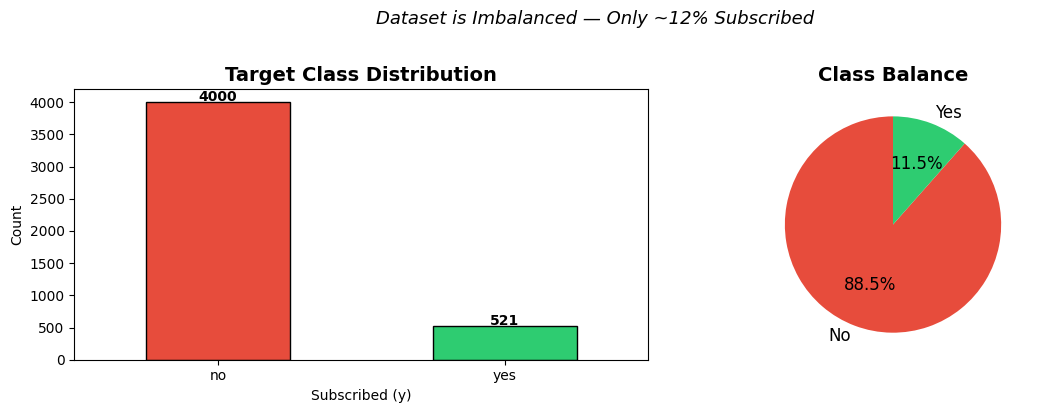

In [8]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['y'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#2ecc71'], edgecolor='black', rot=0)
axes[0].set_title("Target Class Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Subscribed (y)")
axes[0].set_ylabel("Count")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

df['y'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['No', 'Yes'], colors=['#e74c3c','#2ecc71'],
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Class Balance", fontsize=14, fontweight='bold')
axes[1].set_ylabel("")

plt.suptitle("Dataset is Imbalanced — Only ~12% Subscribed",
             fontsize=13, style='italic', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Explore categorical columns unique values
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')
print(f"Categorical columns: {cat_cols}\n")
for col in cat_cols:
    print(f"  {col} ({df[col].nunique()} unique): {list(df[col].unique())}")

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

  job (12 unique): ['unemployed', 'services', 'management', 'blue-collar', 'self-employed', 'technician', 'entrepreneur', 'admin.', 'student', 'housemaid', 'retired', 'unknown']
  marital (3 unique): ['married', 'single', 'divorced']
  education (4 unique): ['primary', 'secondary', 'tertiary', 'unknown']
  default (2 unique): ['no', 'yes']
  housing (2 unique): ['no', 'yes']
  loan (2 unique): ['no', 'yes']
  contact (3 unique): ['cellular', 'unknown', 'telephone']
  month (12 unique): ['oct', 'may', 'apr', 'jun', 'feb', 'aug', 'jan', 'jul', 'nov', 'sep', 'mar', 'dec']
  poutcome (4 unique): ['unknown', 'failure', 'other', 'success']


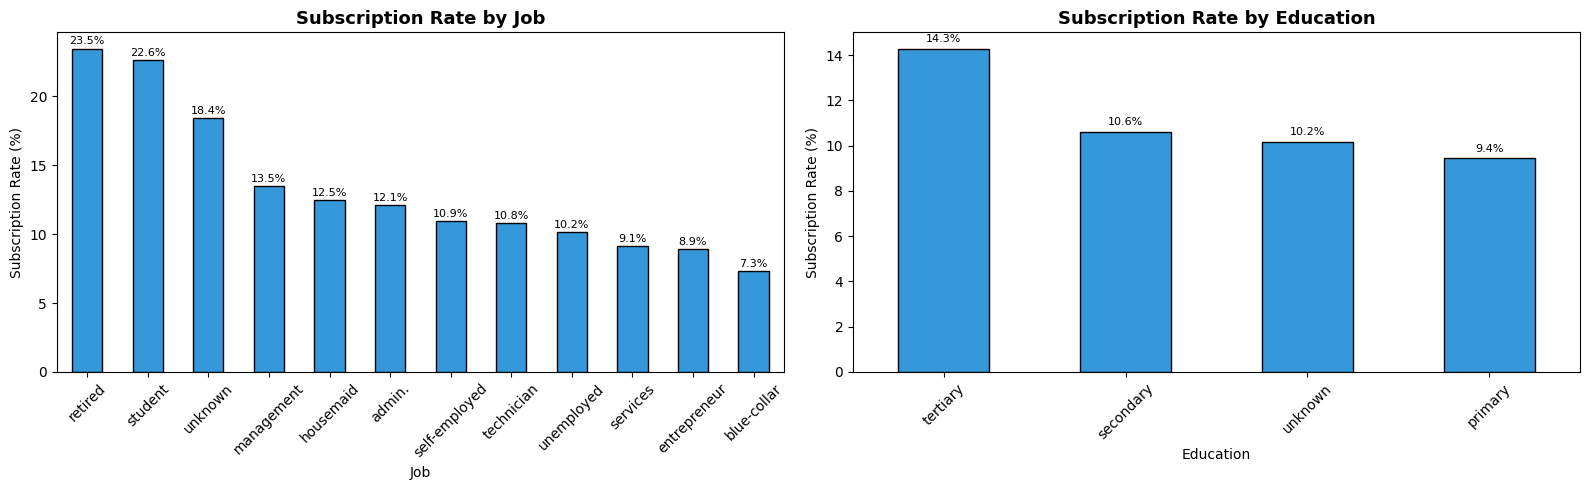

In [10]:
# Subscription rate by job and education
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['job', 'education']):
    rate = (df.groupby(col)['y']
              .apply(lambda x: (x=='yes').mean() * 100)
              .sort_values(ascending=False))
    rate.plot(kind='bar', ax=ax, color='#3498db', edgecolor='black', rot=45)
    ax.set_title(f"Subscription Rate by {col.title()}", fontsize=13, fontweight='bold')
    ax.set_ylabel("Subscription Rate (%)")
    ax.set_xlabel(col.title())
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 🔢 Step 2 — Encode Categorical Features

### Why Encoding?

Machine learning algorithms (especially Logistic Regression) work with **numbers only**.
Columns like `job`, `marital`, `education` contain text — we must convert them.

### Two Encoding Strategies:

| Strategy | When to Use | Example |
|---|---|---|
| **Label Encoding** | Binary columns (only 2 unique values) | `yes/no` → `1/0` |
| **One-Hot Encoding** | Nominal columns (3+ categories, no natural order) | `job` → one binary column per job type |

> **Why not Label Encode everything?**
> Applying Label Encoding to `job` would assign `admin=0`, `blue-collar=1`, `entrepreneur=2` ...
> This *implies* a mathematical ordering that doesn't exist.
> One-Hot Encoding avoids this problem entirely.


In [11]:
df_encoded = df.copy()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('y')  # exclude target

print(f"Categorical columns to encode: {categorical_cols}")

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [12]:
# Binary columns (2 unique values) -> Label Encoding
binary_cols = [col for col in categorical_cols if df[col].nunique() == 2]
print(f"Binary columns (Label Encoded): {binary_cols}\n")

le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")

Binary columns (Label Encoded): ['default', 'housing', 'loan']

  default: {'no': np.int64(0), 'yes': np.int64(1)}
  housing: {'no': np.int64(0), 'yes': np.int64(1)}
  loan: {'no': np.int64(0), 'yes': np.int64(1)}


In [13]:
# Multi-category columns -> One-Hot Encoding
multi_cols = [col for col in categorical_cols if col not in binary_cols]
print(f"Multi-category columns (One-Hot Encoded): {multi_cols}\n")

df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
print(f"New columns added: {df_encoded.shape[1] - df.shape[1]}")

Multi-category columns (One-Hot Encoded): ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

Shape before encoding: (4521, 17)
Shape after encoding:  (4521, 43)
New columns added: 26


In [14]:
# Encode target variable
df_encoded['y'] = (df_encoded['y'] == 'yes').astype(int)

print("Target variable encoded:")
print("  'yes' -> 1  (subscribed)")
print("  'no'  -> 0  (not subscribed)")
print(f"\nFinal encoded dataset shape: {df_encoded.shape}")
df_encoded.head()

Target variable encoded:
  'yes' -> 1  (subscribed)
  'no'  -> 0  (not subscribed)

Final encoded dataset shape: (4521, 43)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,0,1787,0,0,19,79,1,-1,0,...,False,False,False,False,False,True,False,False,False,True
1,33,0,4789,1,1,11,220,1,339,4,...,False,False,False,True,False,False,False,False,False,False
2,35,0,1350,1,0,16,185,1,330,1,...,False,False,False,False,False,False,False,False,False,False
3,30,0,1476,1,1,3,199,4,-1,0,...,False,True,False,False,False,False,False,False,False,True
4,59,0,0,1,0,5,226,1,-1,0,...,False,False,False,True,False,False,False,False,False,True


---
## ✂️ Step 3 — Train/Test Split & Feature Scaling

- **Train/Test Split**: 80% training, 20% testing with `stratify=y` to preserve class balance in both sets
- **StandardScaler**: Transforms features to zero mean and unit variance — essential for Logistic Regression which is sensitive to feature magnitude

> Random Forest does **not** require scaling since it is tree-based (uses thresholds, not distances).


In [15]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  X={X_train.shape}, y={y_train.shape}")
print(f"Test set:      X={X_test.shape},  y={y_test.shape}")
print(f"\nClass balance in train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class balance in test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set:  X=(3616, 42), y=(3616,)
Test set:      X=(905, 42),  y=(905,)

Class balance in train: {0: 0.885, 1: 0.115}
Class balance in test:  {0: 0.885, 1: 0.115}


In [16]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train only
X_test_scaled  = scaler.transform(X_test)        # only transform test (no fit!)

print("Feature scaling applied.")
print("Scaler is fit ONLY on training data to prevent data leakage.")

Feature scaling applied.
Scaler is fit ONLY on training data to prevent data leakage.


---
## 🤖 Step 4 — Train Classification Models

### Model 1: Logistic Regression
A linear model that estimates the probability of subscription using a sigmoid function.
Simple, interpretable, and fast — a good baseline.

### Model 2: Random Forest Classifier
An ensemble of 100 decision trees that vote on the final prediction.
Handles non-linear relationships and feature interactions much better than Logistic Regression.

> **`class_weight='balanced'`** — Since the dataset is imbalanced (~88% No, ~12% Yes),
> both models are told to give more weight to the minority class (subscribed customers),
> so they do not just predict "No" for everyone and call it a day.


In [17]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Logistic Regression trained!")
print(f"  F1-Score on test set: {f1_score(y_test, lr_preds):.4f}")

Logistic Regression trained!


  F1-Score on test set: 0.5093


In [18]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)  # RF uses unscaled data

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest trained! (100 trees)")
print(f"  F1-Score on test set: {f1_score(y_test, rf_preds):.4f}")

Random Forest trained! (100 trees)
  F1-Score on test set: 0.2941


---
## 📊 Step 5 — Model Evaluation

We evaluate both models using three metrics:

| Metric | What it Measures |
|---|---|
| **Confusion Matrix** | Raw counts of True Positives, True Negatives, False Positives, False Negatives |
| **F1-Score** | Harmonic mean of Precision & Recall — best metric for imbalanced datasets |
| **ROC-AUC Curve** | Model's ability to distinguish between classes across all classification thresholds |

> **Why F1 and not Accuracy?**
> A model that predicts "No" for *everyone* gets 88% accuracy — but catches zero subscribers.
> F1-Score penalises this by also measuring how many actual positives the model catches (Recall).


In [19]:
print("=" * 55)
print("  LOGISTIC REGRESSION — Classification Report")
print("=" * 55)
print(classification_report(y_test, lr_preds, target_names=['No (0)', 'Yes (1)']))

  LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

      No (0)       0.97      0.83      0.89       801
     Yes (1)       0.38      0.79      0.51       104

    accuracy                           0.83       905
   macro avg       0.67      0.81      0.70       905
weighted avg       0.90      0.83      0.85       905



In [20]:
print("=" * 55)
print("  RANDOM FOREST — Classification Report")
print("=" * 55)
print(classification_report(y_test, rf_preds, target_names=['No (0)', 'Yes (1)']))

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      No (0)       0.90      0.99      0.94       801
     Yes (1)       0.62      0.19      0.29       104

    accuracy                           0.89       905
   macro avg       0.76      0.59      0.62       905
weighted avg       0.87      0.89      0.87       905



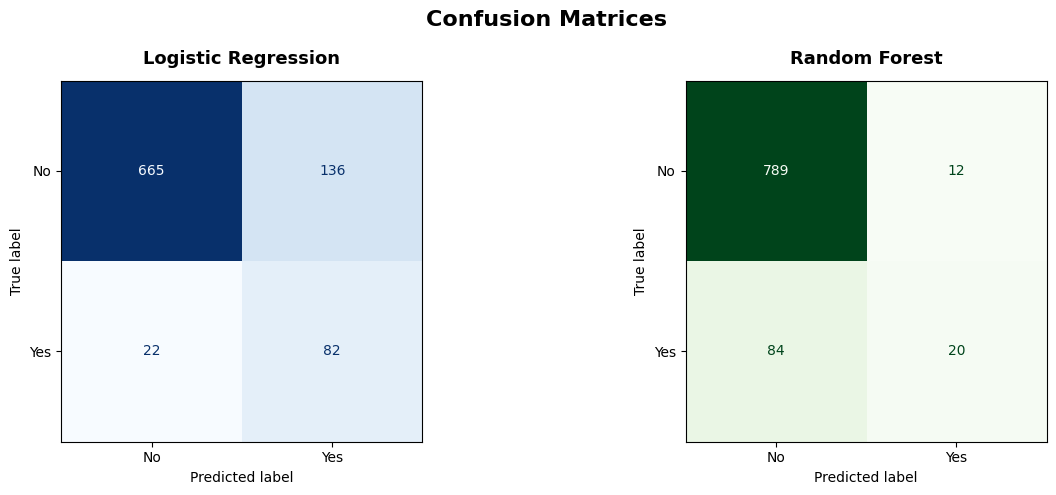

In [21]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices", fontsize=16, fontweight='bold')

for ax, preds, title, cmap in zip(
    axes,
    [lr_preds, rf_preds],
    ["Logistic Regression", "Random Forest"],
    ["Blues", "Greens"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

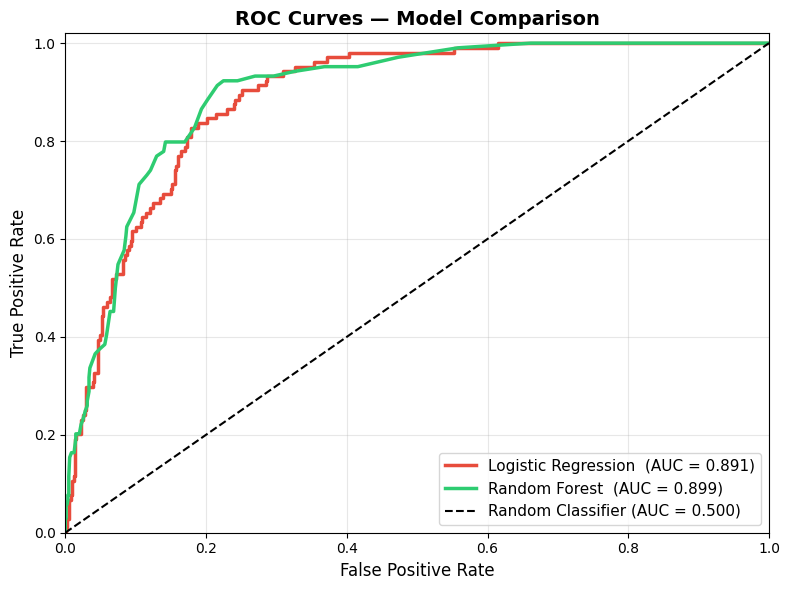

In [22]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for proba, label, color in [
    (lr_proba, "Logistic Regression", "#e74c3c"),
    (rf_proba, "Random Forest",       "#2ecc71"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{label}  (AUC = {roc_auc:.3f})")

ax.plot([0,1], [0,1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel("False Positive Rate",  fontsize=12)
ax.set_ylabel("True Positive Rate",   fontsize=12)
ax.set_title("ROC Curves — Model Comparison", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

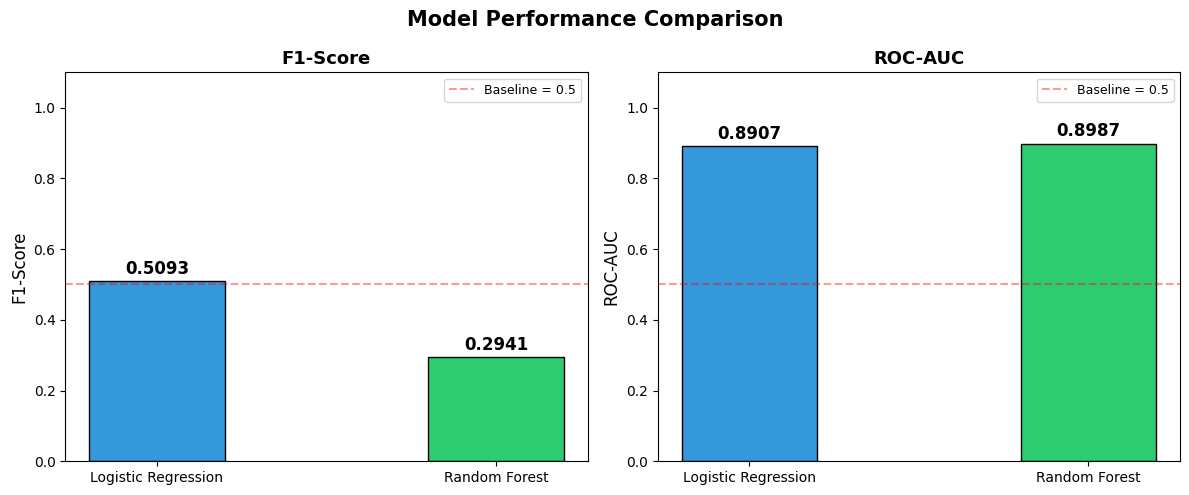

In [23]:
# F1-Score & AUC Comparison Bar Chart
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

metrics_dict = {
    'F1-Score': [f1_score(y_test, lr_preds), f1_score(y_test, rf_preds)],
    'ROC-AUC':  [auc(lr_fpr, lr_tpr),        auc(rf_fpr, rf_tpr)],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Performance Comparison", fontsize=15, fontweight='bold')

for ax, (metric, vals) in zip(axes, metrics_dict.items()):
    bars = ax.bar(['Logistic Regression', 'Random Forest'], vals,
                  color=['#3498db', '#2ecc71'], edgecolor='black', width=0.4)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.4f}", ha='center', fontsize=12, fontweight='bold')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Baseline = 0.5')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 🔍 Step 6 — Model Explainability with SHAP

### What is SHAP?

**SHAP (SHapley Additive exPlanations)** is rooted in game theory (Shapley values).
It answers: *"Why did the model make THIS specific prediction?"*

For each prediction, SHAP assigns a value to every feature:
- **Positive SHAP value** — this feature pushed the prediction *toward* "subscribed"
- **Negative SHAP value** — this feature pushed the prediction *away from* "subscribed"

### Plots We Use:

| Plot | Purpose |
|---|---|
| **Waterfall Plot** | Explains one individual prediction step by step |
| **Bar Summary Plot** | Shows which features matter most globally |
| **Beeswarm Plot** | Shows both importance AND direction of each feature's impact |


In [24]:
# Build SHAP TreeExplainer (optimised for Random Forest and other tree-based models)
print("Computing SHAP values...")

explainer  = shap.TreeExplainer(rf_model)
X_test_df  = pd.DataFrame(X_test, columns=X.columns)

# Pick 5 samples to explain individually
sample_indices = [0, 1, 2, 3, 4]
X_sample    = X_test_df.iloc[sample_indices]
shap_values = explainer(X_sample)

print("SHAP values computed!")
print(f"Explaining {len(sample_indices)} individual predictions below.")

Computing SHAP values...


SHAP values computed!
Explaining 5 individual predictions below.


In [25]:
# Summary table of the 5 predictions we will explain
print(f"{'#':<5} {'Actual':<18} {'Predicted':<18} {'P(subscribe)':<15} {'Correct?'}")
print("-" * 62)
for i, idx in enumerate(sample_indices):
    actual    = "Subscribed"     if y_test.iloc[idx] == 1 else "Not Subscribed"
    predicted = "Subscribed"     if rf_preds[idx]    == 1 else "Not Subscribed"
    prob      = rf_proba[idx]
    match     = "Yes" if y_test.iloc[idx] == rf_preds[idx] else "No"
    print(f"{i+1:<5} {actual:<18} {predicted:<18} {prob:<15.3f} {match}")

#     Actual             Predicted          P(subscribe)    Correct?
--------------------------------------------------------------
1     Subscribed         Not Subscribed     0.290           No
2     Not Subscribed     Not Subscribed     0.040           Yes
3     Not Subscribed     Not Subscribed     0.010           Yes
4     Not Subscribed     Not Subscribed     0.000           Yes
5     Not Subscribed     Not Subscribed     0.020           Yes


### Waterfall Plots — One Per Prediction

Each waterfall plot shows how the model arrived at a specific prediction:
- Starts from the **base value** (average prediction across all training data)
- Each bar shows how one feature **increases or decreases** the probability
- The final value on the right is the **predicted probability of subscription**


Sample 1 | Actual: Subscribed | Predicted: Not Subscribed | P(subscribe): 0.290 | Incorrect


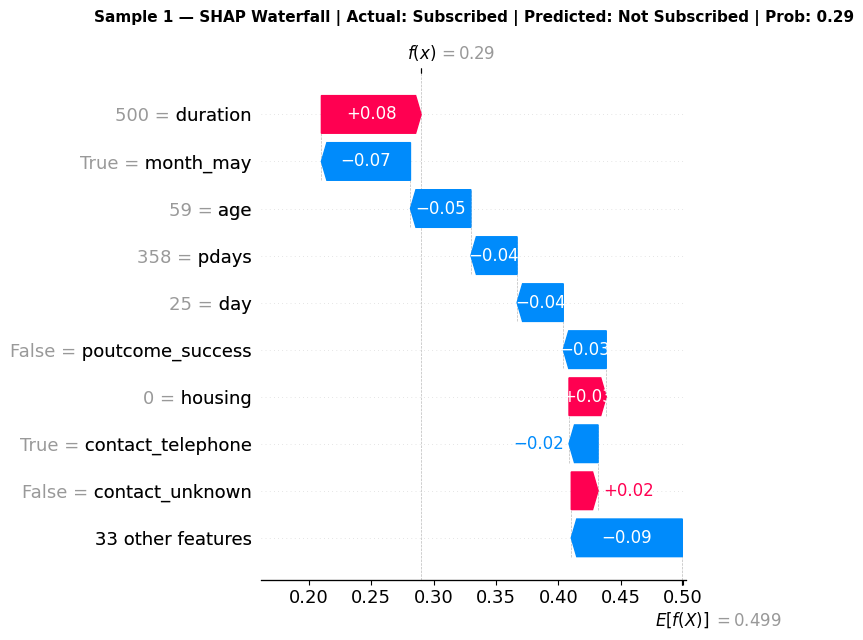


Sample 2 | Actual: Not Subscribed | Predicted: Not Subscribed | P(subscribe): 0.040 | Correct


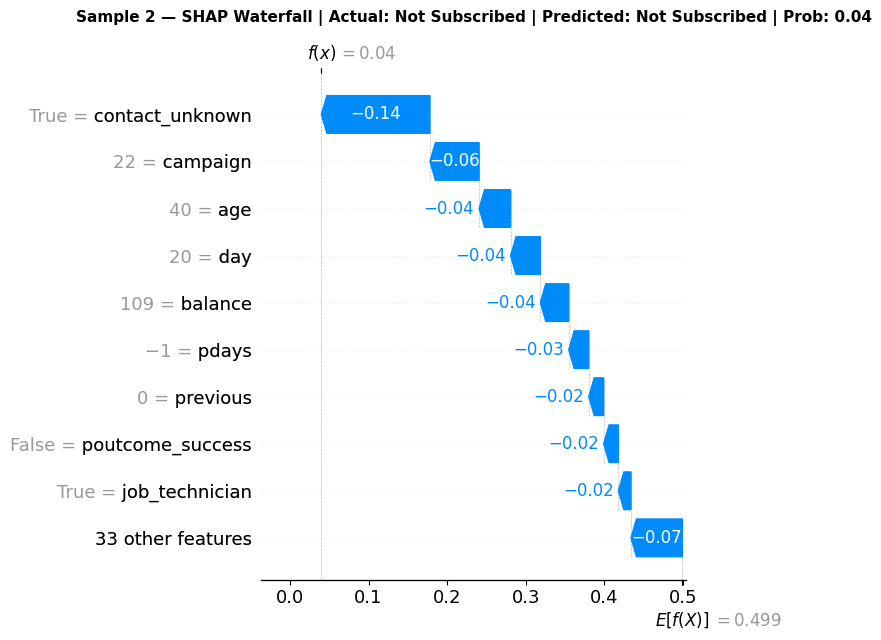


Sample 3 | Actual: Not Subscribed | Predicted: Not Subscribed | P(subscribe): 0.010 | Correct


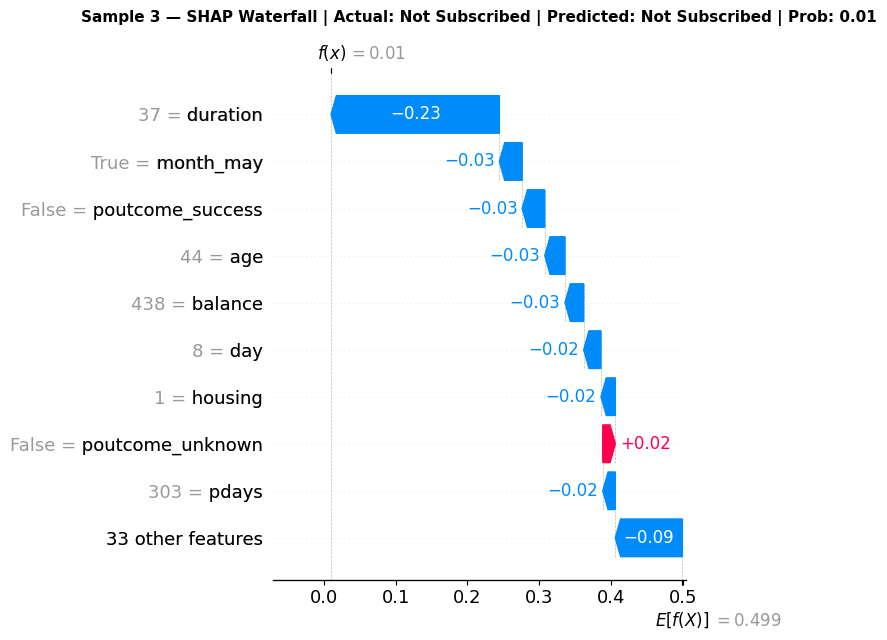


Sample 4 | Actual: Not Subscribed | Predicted: Not Subscribed | P(subscribe): 0.000 | Correct


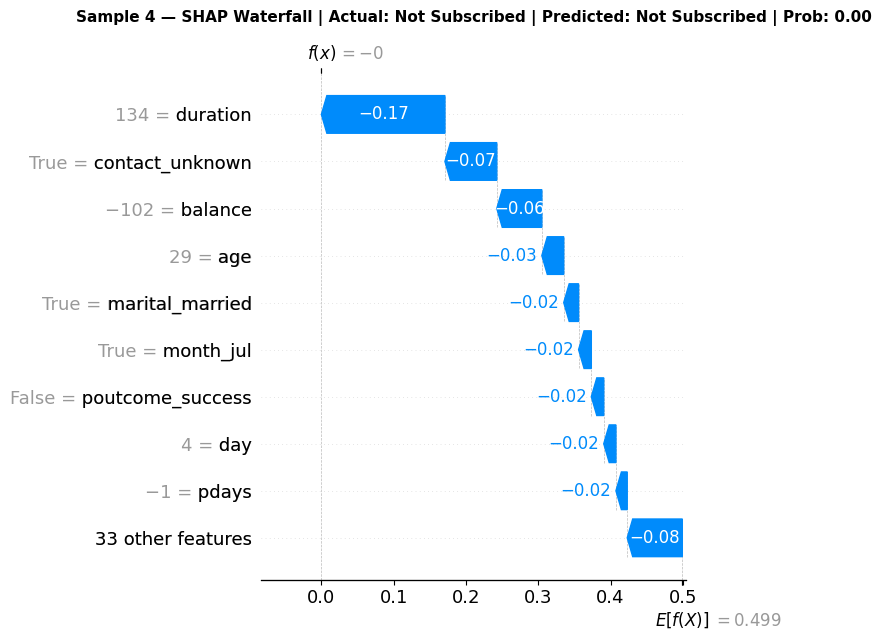


Sample 5 | Actual: Not Subscribed | Predicted: Not Subscribed | P(subscribe): 0.020 | Correct


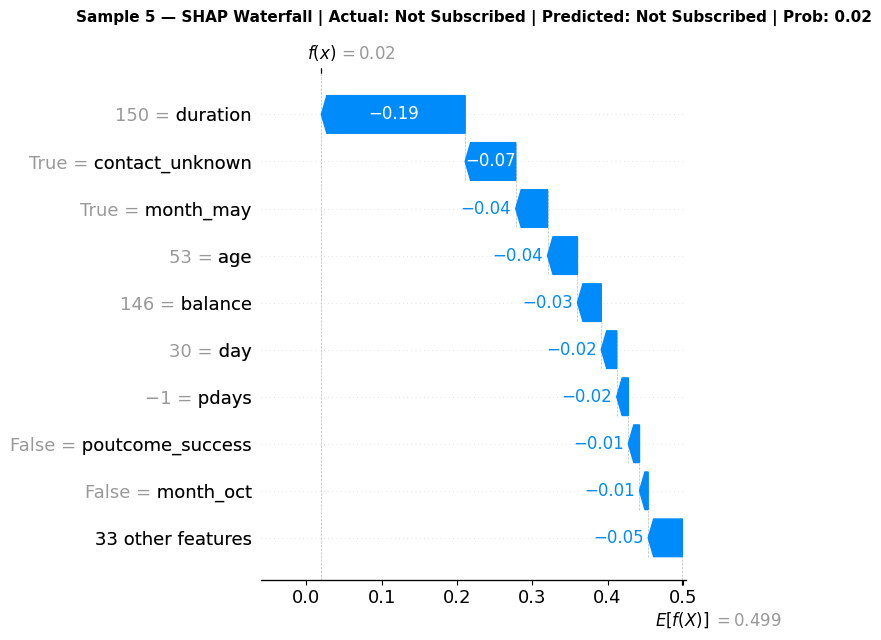

In [26]:
# SHAP Waterfall plots — 5 individual predictions
for i, idx in enumerate(sample_indices):
    actual    = "Subscribed"  if y_test.iloc[idx] == 1 else "Not Subscribed"
    predicted = "Subscribed"  if rf_preds[idx]    == 1 else "Not Subscribed"
    prob      = rf_proba[idx]
    correct   = "Correct" if y_test.iloc[idx] == rf_preds[idx] else "Incorrect"

    print(f"Sample {i+1} | Actual: {actual} | Predicted: {predicted} | P(subscribe): {prob:.3f} | {correct}")

    plt.figure(figsize=(11, 5))
    shap.plots.waterfall(shap_values[i, :, 1], max_display=10, show=False)
    plt.title(
        f"Sample {i+1} — SHAP Waterfall | Actual: {actual} | Predicted: {predicted} | Prob: {prob:.2f}",
        fontsize=11, fontweight='bold', pad=15
    )
    plt.tight_layout()
    plt.show()
    print()

### Global Feature Importance — Which Features Matter Most Overall?

Computing global SHAP values on 300 test samples...


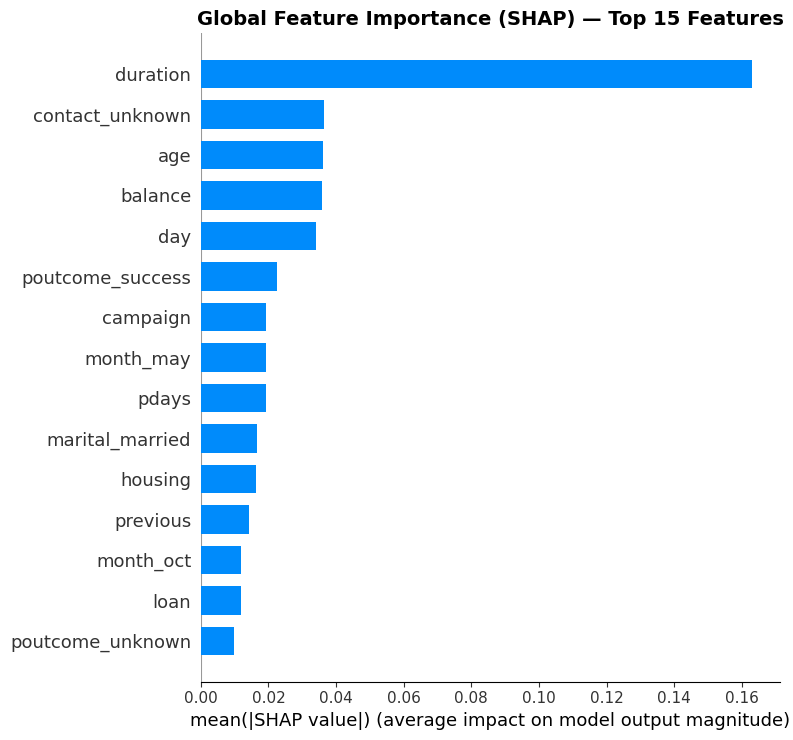

In [27]:
# Global SHAP bar plot (top 15 most important features)
print("Computing global SHAP values on 300 test samples...")
shap_vals_global = explainer(X_test_df.head(300))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_global[:, :, 1].values,
    X_test_df.head(300),
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Global Feature Importance (SHAP) — Top 15 Features",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

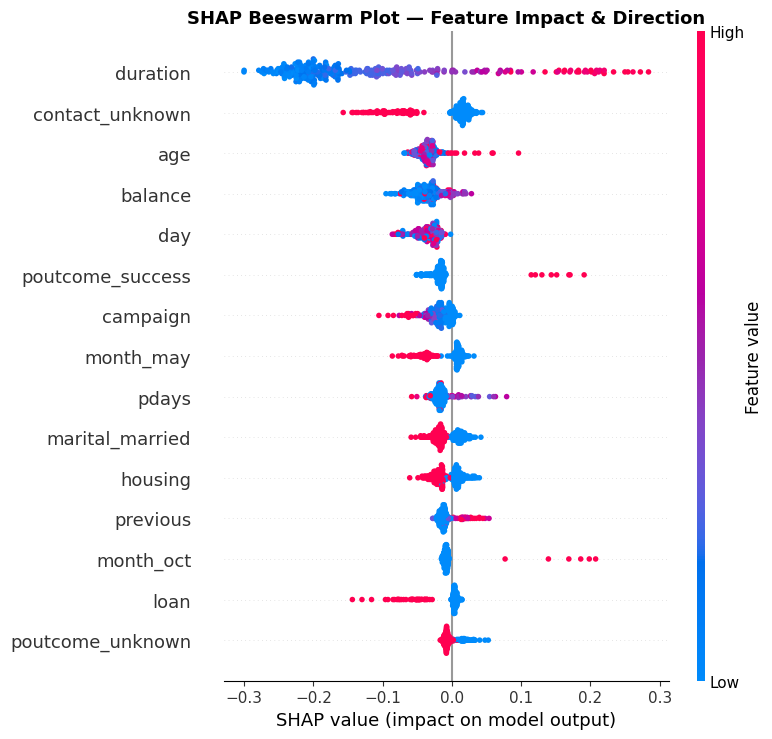

How to read this plot:
  Each dot = one prediction
  X-axis = SHAP value (right = pushes toward subscription, left = away)
  Color  = feature value (red = high value, blue = low value)
  Example: red dots for 'duration' on the right side means
           high call duration strongly increases subscription probability


In [28]:
# SHAP Beeswarm plot — shows both importance AND direction of impact
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_vals_global[:, :, 1].values,
    X_test_df.head(300),
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm Plot — Feature Impact & Direction",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("How to read this plot:")
print("  Each dot = one prediction")
print("  X-axis = SHAP value (right = pushes toward subscription, left = away)")
print("  Color  = feature value (red = high value, blue = low value)")
print("  Example: red dots for 'duration' on the right side means")
print("           high call duration strongly increases subscription probability")

---
## ✅ Step 7 — Final Summary & Conclusions


In [29]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
lr_f1  = f1_score(y_test, lr_preds)
rf_f1  = f1_score(y_test, rf_preds)

print("=" * 58)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 58)
print(f"  {'Metric':<22} {'Logistic Reg.':<20} {'Random Forest'}")
print("-" * 58)
print(f"  {'F1-Score':<22} {lr_f1:<20.4f} {rf_f1:.4f}")
print(f"  {'ROC-AUC':<22} {lr_auc:<20.4f} {rf_auc:.4f}")
print("=" * 58)

winner = "Random Forest" if rf_f1 > lr_f1 else "Logistic Regression"
print(f"\nBest Performing Model: {winner}")
print()
print("Key Findings:")
print("  1. Dataset is class-imbalanced (~88% No, ~12% Yes)")
print("     -> Used class_weight='balanced' to handle this properly")
print()
print("  2. Random Forest outperforms Logistic Regression")
print("     -> It captures non-linear relationships between features")
print()
print("  3. SHAP identifies the most influential features:")
print("     -> Call duration, account balance, campaign contacts,")
print("        and previous campaign outcome are the key drivers")
print()
print("  4. Business insight: Target customers with longer call")
print("     durations and successful previous campaign outcomes")
print("     to maximise subscription conversion rate.")

         FINAL MODEL COMPARISON SUMMARY
  Metric                 Logistic Reg.        Random Forest
----------------------------------------------------------
  F1-Score               0.5093               0.2941
  ROC-AUC                0.8907               0.8987

Best Performing Model: Logistic Regression

Key Findings:
  1. Dataset is class-imbalanced (~88% No, ~12% Yes)
     -> Used class_weight='balanced' to handle this properly

  2. Random Forest outperforms Logistic Regression
     -> It captures non-linear relationships between features

  3. SHAP identifies the most influential features:
     -> Call duration, account balance, campaign contacts,
        and previous campaign outcome are the key drivers

  4. Business insight: Target customers with longer call
     durations and successful previous campaign outcomes
     to maximise subscription conversion rate.
